# Рекомендации на главной: данные и факторы

Дипломный проект SkillFactory

**Рубинштейн Андрей**

Клиент - интернет-магазин. На главной три места под товары, задача - поднять оборот за счёт допродаж. Оборот - бизнес-метрика, офлайн по логу её честно не померить, поэтому техническая метрика - Precision@3: сколько из трёх показанных товаров человек потом купил

Здесь разбираю данные от клиента, строю валидацию по времени и считаю факторы для модели. Описания данных нет, аналитик клиента в отпуске, так что что где лежит, выясняю сам

Разделы: [данные](#sec-data), [статистика](#sec-eda), [валидация](#sec-split), [факторы](#sec-feat), [проверка факторов](#sec-check), [датасет для обучения](#sec-dataset), [итоги](#sec-sum)

In [1]:
%matplotlib inline
from pathlib import Path

import matplotlib.dates as mdates
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import numpy as np
import pandas as pd
import seaborn as sns
from scipy import stats

RAW = Path("data/raw")
OUT = Path("data/processed")
OUT.mkdir(parents=True, exist_ok=True)

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 50)
COLOR = "steelblue"
LIGHT = "lightsteelblue"
EVENT_TYPES = ["view", "addtocart", "transaction"]

<a id="sec-data"></a>

## 1. Данные

### Лог событий

In [2]:
events = pd.read_csv(RAW / "events.csv")
print(events.shape)
print(events.dtypes)
events.head()

(2756101, 5)
timestamp          int64
visitorid          int64
event                str
itemid             int64
transactionid    float64
dtype: object


,timestamp,visitorid,event,itemid,transactionid
0,1433221332117,257597,view,355908,NaN
1,1433224214164,992329,view,248676,NaN
2,1433221999827,111016,view,318965,NaN
3,1433221955914,483717,view,253185,NaN
4,1433221337106,951259,view,367447,NaN


In [3]:
print("пропуски:")
print(events.isna().sum())
print()
print("полных дублей:", events.duplicated().sum())
print()
print("доля заполненного transactionid по типу события:")
print(events.groupby("event")["transactionid"].apply(lambda s: s.notna().mean()))

пропуски:
timestamp              0
visitorid              0
event                  0
itemid                 0
transactionid    2733644
dtype: int64

полных дублей: 460

доля заполненного transactionid по типу события:
event
addtocart      0.0
transaction    1.0
view           0.0
Name: transactionid, dtype: float64


`transactionid` есть только у покупок, у просмотров и корзины пусто - так и должно быть

460 полных дублей: тот же человек, товар, событие и миллисекунда. Похоже на двойную запись в логе, выкидываю. Время из миллисекунд перевожу в дату

In [4]:
events = events.drop_duplicates().reset_index(drop=True)
events["dt"] = pd.to_datetime(events["timestamp"], unit="ms")
events["day"] = events["dt"].dt.normalize()

print("период:", events["dt"].min(), "-", events["dt"].max())
print("дней:", events["day"].nunique())
print("посетителей:", events["visitorid"].nunique())
print("товаров:", events["itemid"].nunique())
print("чеков (transactionid):", events["transactionid"].nunique())
print()
print(events["event"].value_counts())

период: 2015-05-03 03:00:04.384000 - 2015-09-18 02:59:47.788000
дней: 139
посетителей: 1407580
товаров: 235061
чеков (transactionid): 17672

event
view           2664218
addtocart        68966
transaction      22457
Name: count, dtype: int64


Четыре с половиной месяца, 1.4 млн посетителей и 235 тысяч товаров. Просмотров в сотню раз больше, чем покупок. 22 тысячи покупок лежат в 17.7 тысячи чеков, в чеке обычно один товар

### Свойства товаров

In [5]:
props = pd.concat(
    [pd.read_csv(RAW / f"item_properties_part{i}.csv") for i in (1, 2)],
    ignore_index=True,
)
props["dt"] = pd.to_datetime(props["timestamp"], unit="ms")

print(props.shape)
print("память, ГБ:", round(props.memory_usage(deep=True).sum() / 1e9, 2))
print("снимков:", props["dt"].nunique(), "|", props["dt"].min(), "-", props["dt"].max())
print("дни недели снимков:", props["dt"].dt.day_name().unique())
print("уникальных свойств:", props["property"].nunique())
print("товаров со свойствами:", props["itemid"].nunique())
props.head()

(20275902, 5)
память, ГБ: 1.24
снимков: 18 | 2015-05-10 03:00:00 - 2015-09-13 03:00:00
дни недели снимков: <ArrowStringArray>
['Sunday']
Length: 1, dtype: str
уникальных свойств: 1104
товаров со свойствами: 417053


,timestamp,itemid,property,value,dt
0,1435460400000,460429,categoryid,1338,2015-06-28 03:00:00
1,1441508400000,206783,888,1116713 960601 n277.200,2015-09-06 03:00:00
2,1439089200000,395014,400,n552.000 639502 n720.000 424566,2015-08-09 03:00:00
3,1431226800000,59481,790,n15360.000,2015-05-10 03:00:00
4,1431831600000,156781,917,828513,2015-05-17 03:00:00


In [6]:
rec_per_pair = props.groupby(["itemid", "property"]).size()
print("пар товар-свойство с одной записью:", round((rec_per_pair == 1).mean(), 3))
print()
print("самые частые свойства:")
print(props["property"].value_counts().head(8))
print()
named = [p for p in props["property"].unique() if not p.isdigit()]
print("незахешированные свойства:", named)
print()
for prop in ["categoryid", "available", "790", "888"]:
    print(prop, props.loc[props["property"] == prop, "value"].head(4).tolist())

пар товар-свойство с одной записью: 0.957

самые частые свойства:
property
888           3000398
790           1790516
available     1503639
categoryid     788214
6              631471
283            597419
776            574220
678            481966
Name: count, dtype: int64

незахешированные свойства: ['categoryid', 'available']

categoryid ['1338', '1277', '1059', '1147']
available ['0', '0', '0', '1']
790 ['n15360.000', 'n21000.000', 'n5400.000', 'n39588.000']
888 ['1116713 960601 n277.200', '1038400 45956 n504.000', '1292080', '150169 176547 824301 24474 293011 1240134']


Снимки свойств - по воскресеньям, 18 недель. У 96% пар товар-свойство одна запись, то есть пишется первое значение и потом только изменения, а не копия каждую неделю

Читаются два свойства: `categoryid` и `available` (0/1). Остальное захешировано вместе со значениями. Выделяется `790`: там всегда число с префиксом `n`, и меняется оно чаще остальных. Очень похоже на цену, возьму как числовой `price`, хоть валюта и масштаб неизвестны

Остальные ~1100 хешей пока не трогаю. Без расшифровки это тысячи разреженных категорий

In [7]:
cat_hist = props[props["property"] == "categoryid"]
avail_hist = props[props["property"] == "available"]
n_cat = cat_hist.groupby("itemid")["value"].nunique()
n_avail = avail_hist.groupby("itemid")["value"].nunique()
print("товаров меняли категорию:", (n_cat > 1).sum(), "из", len(n_cat))
print("доля товаров, у которых менялась доступность:", round((n_avail > 1).mean(), 3))
print("доля записей available = 1:", round((avail_hist["value"] == "1").mean(), 3))

event_items = events["itemid"].drop_duplicates()
print("товары из событий, у которых есть свойства:",
      round(event_items.isin(props["itemid"]).mean(), 3))

товаров меняли категорию: 23352 из 417053
доля товаров, у которых менялась доступность: 0.161
доля записей available = 1: 0.426
товары из событий, у которых есть свойства: 0.788


Свойства меняются: у 23 тысяч товаров менялась категория, у 16% доступность. Значит, на момент среза беру последнее значение до среза, а не последнее в файле, иначе подгляжу в будущее

У 21% товаров из лога свойств нет совсем, категория и цена у них будут пропусками. Оставляю три нужных свойства в маленькой таблице, большой датафрейм удаляю

In [8]:
keep = {"categoryid": "category", "available": "available", "790": "price"}
prop_hist = props[props["property"].isin(keep)].copy()
prop_hist["property"] = prop_hist["property"].map(keep)
prop_hist["value"] = prop_hist["value"].str.lstrip("n").astype(float)
prop_hist = prop_hist[["itemid", "property", "value", "dt"]].sort_values("dt")
del props, rec_per_pair

print(prop_hist["property"].value_counts())
print(prop_hist.groupby("property")["value"].describe().round(1))

property
price        1790516
available    1503639
category      788214
Name: count, dtype: int64
               count      mean        std  min      25%      50%       75%  \
property                                                                     
available  1503639.0       0.4        0.5  0.0      0.0      0.0       1.0   
category    788214.0     880.5      480.9  0.0    463.0    967.0    1277.0   
price      1790516.0  128904.9  2148822.1  0.0  16320.0  46320.0  125760.0   

                    max  
property                 
available  1.000000e+00  
category   1.697000e+03  
price      1.200000e+09  


### Дерево категорий

In [9]:
tree = pd.read_csv(RAW / "category_tree.csv")
parent = tree.set_index("categoryid")["parentid"].to_dict()


def category_path(cat_id):
    path = [cat_id]
    while pd.notna(parent.get(path[-1], np.nan)):
        path.append(int(parent[path[-1]]))
    return path


tree["depth"] = tree["categoryid"].map(lambda c: len(category_path(c)) - 1)
tree["root"] = tree["categoryid"].map(lambda c: category_path(c)[-1])
cat_root = tree.set_index("categoryid")["root"]
cat_depth = tree.set_index("categoryid")["depth"]

print(tree.shape, "| корней:", tree["parentid"].isna().sum())
print("глубина:", tree["depth"].value_counts().sort_index().to_dict())

item_cats = cat_hist["value"].astype(int).unique()
leaves = set(tree["categoryid"]) - set(tree["parentid"].dropna())
print("категорий у товаров:", len(item_cats))
print("из них есть в дереве:", round(np.isin(item_cats, tree["categoryid"]).mean(), 3))
print("из них листья:", round(np.isin(item_cats, list(leaves)).mean(), 3))

(1669, 4) | корней: 25
глубина: {0: 25, 1: 174, 2: 702, 3: 665, 4: 90, 5: 13}
категорий у товаров: 1242
из них есть в дереве: 0.976
из них листья: 0.915


Дерево неглубокое: 25 корней, до пяти уровней, товары висят в основном на листьях. Из дерева беру корень (крупный раздел) и глубину. Двух с небольшим процентов категорий в дереве нет, у таких товаров корень будет пропуском

<a id="sec-eda"></a>

## 2. Статистика

### Воронка

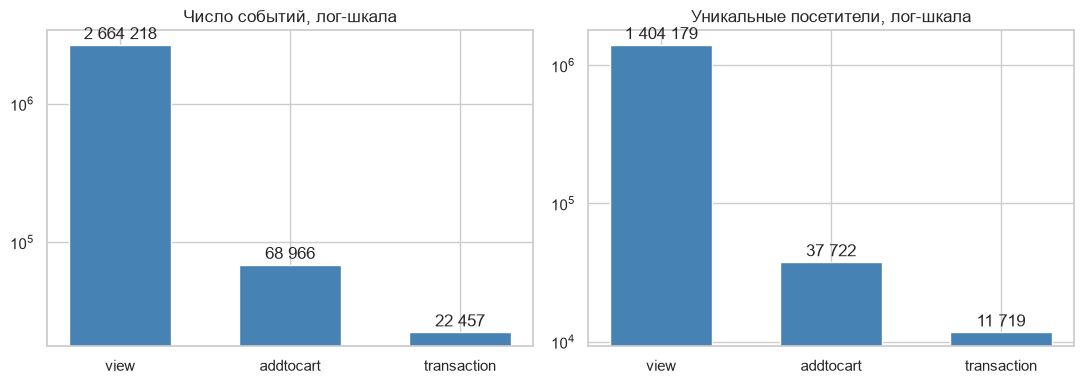

событий: корзина / просмотр = 2.59%, покупка / просмотр = 0.84%
посетителей: хоть раз купили 0.83% от смотревших


In [10]:
counts = events["event"].value_counts().reindex(EVENT_TYPES)
users_by_event = events.groupby("event")["visitorid"].nunique().reindex(EVENT_TYPES)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, s, title in zip(
    axes,
    [counts, users_by_event],
    ["Число событий", "Уникальные посетители"],
):
    ax.bar(s.index, s.values, color=COLOR, width=0.6)
    ax.set_yscale("log")
    ax.set_title(title + ", лог-шкала")
    for i, v in enumerate(s.values):
        ax.text(i, v * 1.1, f"{v:,}".replace(",", " "), ha="center")
plt.tight_layout()
plt.show()

print("событий: корзина / просмотр = %.2f%%, покупка / просмотр = %.2f%%"
      % (counts["addtocart"] / counts["view"] * 100,
         counts["transaction"] / counts["view"] * 100))
print("посетителей: хоть раз купили %.2f%% от смотревших"
      % (users_by_event["transaction"] / users_by_event["view"] * 100))

Покупает меньше процента посетителей. Классы будут сильно несбалансированы, и Precision@3 в абсолютных цифрах выйдет маленьким при любой модели

### Динамика по дням и часам

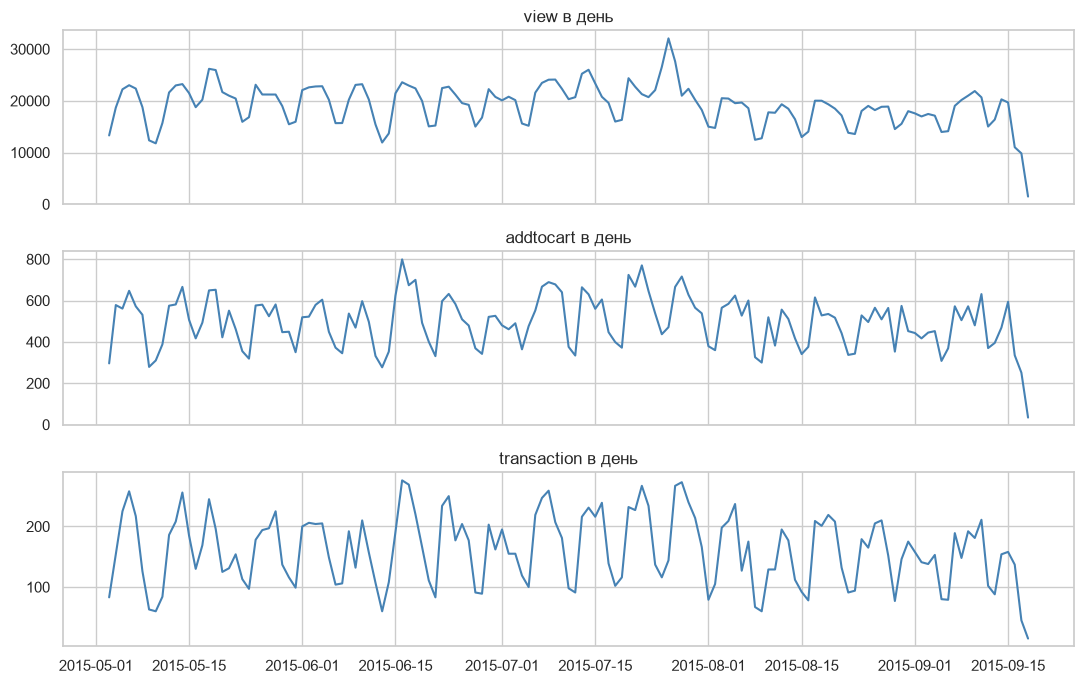

event     view  addtocart  transaction
count    139.0      139.0        139.0
mean   19167.0      496.0        162.0
std     4024.0      125.0         58.0
min     1479.0       34.0         15.0
25%    16344.0      392.0        112.0
50%    19961.0      509.0        162.0
75%    21788.0      580.0        208.0
max    32077.0      799.0        276.0


In [11]:
daily = events.groupby(["day", "event"]).size().unstack()[EVENT_TYPES]

fig, axes = plt.subplots(3, 1, figsize=(11, 7), sharex=True)
for ax, ev_type in zip(axes, EVENT_TYPES):
    ax.plot(daily.index, daily[ev_type], color=COLOR, lw=1.5)
    ax.set_title(ev_type + " в день")
plt.tight_layout()
plt.show()

print(daily.describe().round(0))

Провалов нет. Недельная сезонность видна сразу, в конце июля пик просмотров, в августе-сентябре смотрят чуть меньше, чем летом. Покупки держатся ровно. Последний день неполный: лог обрывается 18 сентября в 3 ночи. Аномальных недель нет, срезы по неделям можно сравнивать

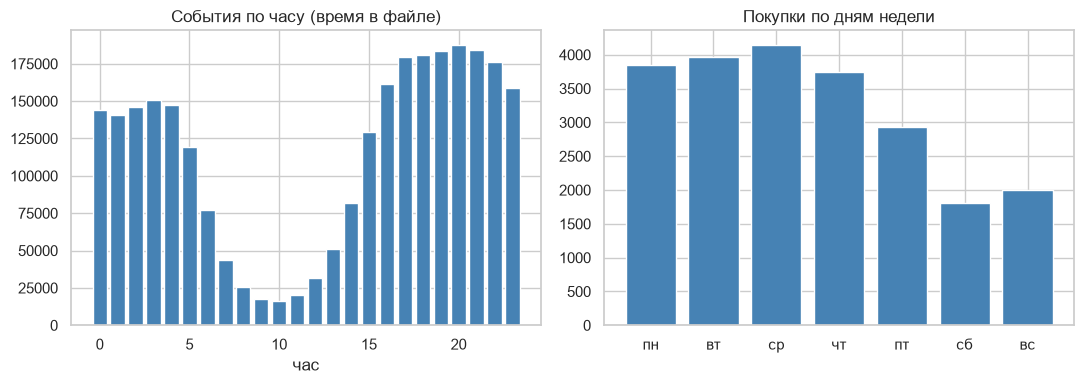

In [12]:
hourly = events["dt"].dt.hour.value_counts().sort_index()
is_trans = events["event"] == "transaction"
weekday = events.loc[is_trans, "dt"].dt.dayofweek.value_counts().sort_index()

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].bar(hourly.index, hourly.values, color=COLOR)
axes[0].set_title("События по часу (время в файле)")
axes[0].set_xlabel("час")
axes[1].bar(["пн", "вт", "ср", "чт", "пт", "сб", "вс"], weekday.values, color=COLOR)
axes[1].set_title("Покупки по дням недели")
plt.tight_layout()
plt.show()

Меньше всего событий в 9-11 часов по времени файла, больше всего в 17-21. Для Москвы странно, скорее всего это UTC, а магазин в другом поясе. Мне это не мешает, в факторах только относительное время - сколько дней до среза. Покупают в будни, в выходные примерно вдвое меньше

### Пользователи

         n_events  n_sessions      n_days
count  1407580.00  1407580.00  1407580.00
mean         1.96        1.25        1.17
std         12.58        1.82        0.93
min          1.00        1.00        1.00
50%          1.00        1.00        1.00
75%          2.00        1.00        1.00
90%          3.00        2.00        2.00
99%         13.00        5.00        4.00
max       7757.00      462.00      131.00

доля с одним событием: 0.712
доля, заходивших больше одного дня: 0.102


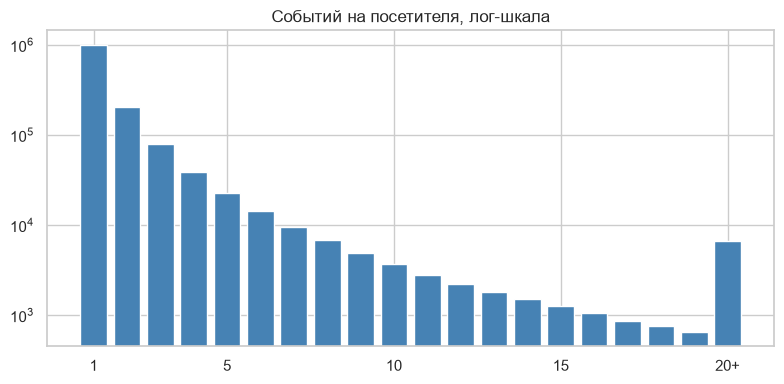

In [13]:
events = events.sort_values(["visitorid", "timestamp"]).reset_index(drop=True)
gap = events.groupby("visitorid")["timestamp"].diff()
events["session"] = (gap.isna() | (gap > 30 * 60 * 1000)).cumsum()

user_stats = events.groupby("visitorid").agg(
    n_events=("event", "size"),
    n_sessions=("session", "nunique"),
    n_days=("day", "nunique"),
)
print(user_stats.describe(percentiles=[0.5, 0.75, 0.9, 0.99]).round(2))
print()
print("доля с одним событием:", round((user_stats["n_events"] == 1).mean(), 3))
print("доля, заходивших больше одного дня:", round((user_stats["n_days"] > 1).mean(), 3))

fig, ax = plt.subplots(figsize=(8, 4))
clipped = user_stats["n_events"].clip(upper=20).value_counts().sort_index()
ax.bar(clipped.index, clipped.values, color=COLOR)
ax.set_yscale("log")
ax.set_xticks([1, 5, 10, 15, 20])
ax.set_xticklabels(["1", "5", "10", "15", "20+"])
ax.set_title("Событий на посетителя, лог-шкала")
plt.tight_layout()
plt.show()

Сессию режу по паузе больше 30 минут. 71% посетителей сделали одно действие и ушли, больше одного дня заходили 10%. То есть почти все - разовые гости без истории. Для главной это важно, ниже посчитаю точнее

### Товары

view: товаров 234838, топ-1% товаров дают 22.7% событий
transaction: товаров 12025, топ-1% товаров дают 10.1% событий


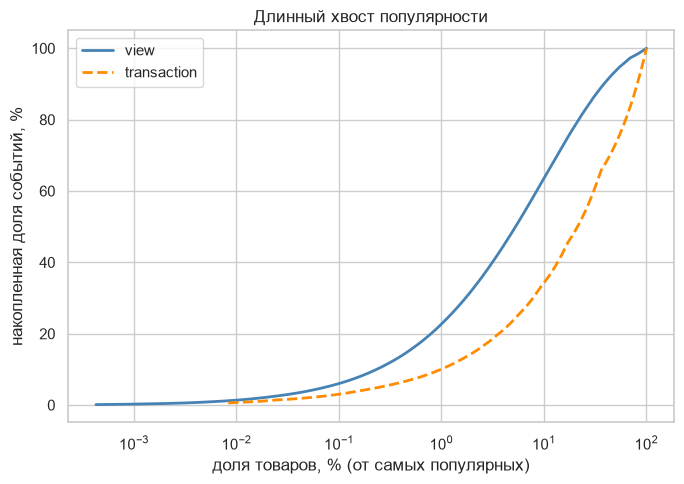

In [14]:
fig, ax = plt.subplots(figsize=(7, 5))
for ev_type, color, ls in [("view", COLOR, "-"), ("transaction", "darkorange", "--")]:
    pop = events.loc[events["event"] == ev_type, "itemid"].value_counts().to_numpy()
    x = np.arange(1, len(pop) + 1) / len(pop)
    y = pop.cumsum() / pop.sum()
    ax.plot(x * 100, y * 100, color=color, ls=ls, lw=2, label=ev_type)
    top1 = y[int(len(pop) * 0.01) - 1] * 100
    print(f"{ev_type}: товаров {len(pop)}, топ-1% товаров дают {top1:.1f}% событий")
ax.set_xscale("log")
ax.set_xlabel("доля товаров, % (от самых популярных)")
ax.set_ylabel("накопленная доля событий, %")
ax.set_title("Длинный хвост популярности")
ax.legend()
plt.tight_layout()
plt.show()

Хвост длинный. Топ-1% товаров собирает пятую часть просмотров, а покупки размазаны ещё сильнее: куплено 12 тысяч разных товаров, самый популярный - 133 раза. Отсюда и 0.61% у топ-3 по продажам. Один список на всех не сработает

### Покупки

In [15]:
tr = events[events["event"] == "transaction"]
per_check = tr.groupby("transactionid").size()
print("товаров в чеке:", per_check.describe().round(2).to_dict())

first_view = (events[events["event"] == "view"]
              .groupby(["visitorid", "itemid"])["timestamp"].min().rename("first_view"))
first_cart = (events[events["event"] == "addtocart"]
              .groupby(["visitorid", "itemid"])["timestamp"].min().rename("first_cart"))
tr2 = tr.join(first_view, on=["visitorid", "itemid"])
tr2 = tr2.join(first_cart, on=["visitorid", "itemid"])
print("покупки, перед которыми был просмотр этого товара:",
      round((tr2["first_view"] < tr2["timestamp"]).mean(), 3))
print("покупки, перед которыми была корзина:",
      round((tr2["first_cart"] <= tr2["timestamp"]).mean(), 3))
hours = (tr2["timestamp"] - tr2["first_view"]) / 3.6e6
print("часов от первого просмотра до покупки, медиана:", round(hours.median(), 2))
print("доля покупок в пределах суток от просмотра:", round((hours <= 24).mean(), 3))
repeat = tr.groupby(["visitorid", "itemid"]).size()
print("пар человек-товар с повторной покупкой:", round((repeat > 1).mean(), 3))

товаров в чеке: {'count': 17672.0, 'mean': 1.27, 'std': 0.97, 'min': 1.0, '25%': 1.0, '50%': 1.0, '75%': 1.0, 'max': 31.0}
покупки, перед которыми был просмотр этого товара: 0.883
покупки, перед которыми была корзина: 0.891
часов от первого просмотра до покупки, медиана: 0.17
доля покупок в пределах суток от просмотра: 0.799
пар человек-товар с повторной покупкой: 0.046


Почти всегда покупают то, что смотрели и клали в корзину, и обычно в той же сессии: от просмотра до покупки в медиане 10 минут. Тот же товар повторно берут в 5% пар, так что купленное рекомендовать почти бесполезно. Свежие просмотры и корзина - главные сигналы

### Категории и цена

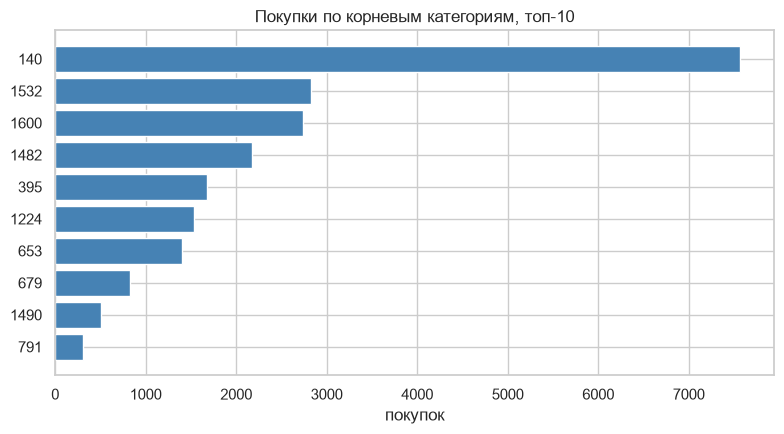

                  покупок  покупок на 100 просмотров
корень категории                                    
140.0                7563                       1.09
1532.0               2823                       0.87
1600.0               2742                       0.84
1482.0               2174                       0.80
395.0                1676                       0.80
1224.0               1537                       1.91
653.0                1399                       0.78
679.0                 824                       0.86
1490.0                506                       0.57
791.0                 305                       0.90


In [16]:
last_cat = prop_hist[prop_hist["property"] == "category"].groupby("itemid")["value"].last()
last_price = prop_hist[prop_hist["property"] == "price"].groupby("itemid")["value"].last()

root_trans = tr["itemid"].map(last_cat).map(cat_root).value_counts().head(10)
view_items = events.loc[events["event"] == "view", "itemid"]
root_views = view_items.map(last_cat).map(cat_root).value_counts()
conv = (root_trans / root_views.reindex(root_trans.index) * 100).round(2)

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.barh(root_trans.index.astype(int).astype(str)[::-1], root_trans.values[::-1], color=COLOR)
ax.set_title("Покупки по корневым категориям, топ-10")
ax.set_xlabel("покупок")
plt.tight_layout()
plt.show()
print(pd.DataFrame({"покупок": root_trans, "покупок на 100 просмотров": conv})
      .rename_axis("корень категории"))

Покупки сидят в нескольких корневых разделах, и конверсия у разделов разная, от 0.6 до 1.9 покупки на 100 просмотров. Корень и популярность категории беру в факторы

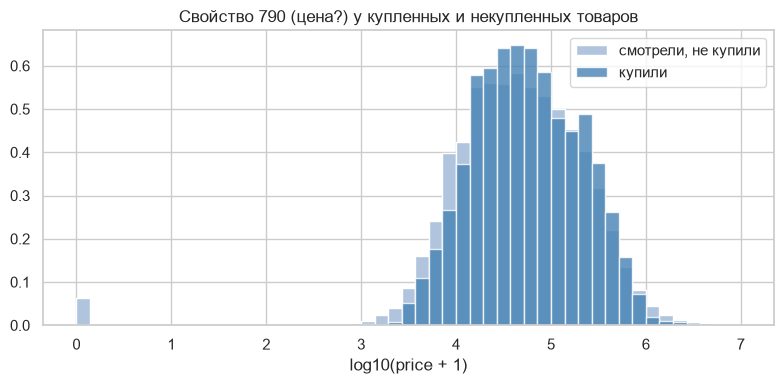

медиана: купили 53040, не купили 45684
Манн-Уитни U=1079905244 p=1.81e-36


In [17]:
viewed_items = events.loc[events["event"] == "view", "itemid"].unique()
bought_items = tr["itemid"].unique()
price_bought = last_price.reindex(bought_items).dropna()
price_not = last_price.reindex(np.setdiff1d(viewed_items, bought_items)).dropna()

fig, ax = plt.subplots(figsize=(8, 4))
bins = np.linspace(0, 7, 50)
ax.hist(np.log10(price_not + 1), bins=bins, color=LIGHT, density=True,
        label="смотрели, не купили")
ax.hist(np.log10(price_bought + 1), bins=bins, color=COLOR, density=True,
        alpha=0.8, label="купили")
ax.set_xlabel("log10(price + 1)")
ax.set_title("Свойство 790 (цена?) у купленных и некупленных товаров")
ax.legend()
plt.tight_layout()
plt.show()

u, p = stats.mannwhitneyu(price_bought, price_not, alternative="two-sided")
print("медиана: купили %.0f, не купили %.0f" % (price_bought.median(), price_not.median()))
print("Манн-Уитни U=%.0f p=%.2e" % (u, p))

Проверю, отличается ли `790` у купленных товаров. На глаз распределения почти одинаковые, только у некупленных есть кучка нулей. Манн-Уитни разницу находит, медиана у купленных чуть выше. Но на десятках тысяч товаров тест цепляется и за мелкий сдвиг, так что сильным фактором цена вряд ли будет. В модель всё равно беру

### Холодный старт

Для главной самое важное - у скольких посетителей вообще есть история, по которой можно подбирать товары. Беру срез 4 сентября и неделю после него

активных посетителей за неделю: 77005 | покупок: 1022
                    посетители с историей  покупатели с историей  \
окно истории, дней                                                 
7                                     4.1                   22.0   
14                                    5.5                   26.0   
28                                    7.2                   28.8   
56                                    9.4                   32.4   
84                                   10.7                   33.8   
112                                  11.8                   35.1   

                    покупки товара из истории  
окно истории, дней                             
7                                         4.5  
14                                        5.8  
28                                        7.5  
56                                        8.2  
84                                        8.6  
112                                       8.6  


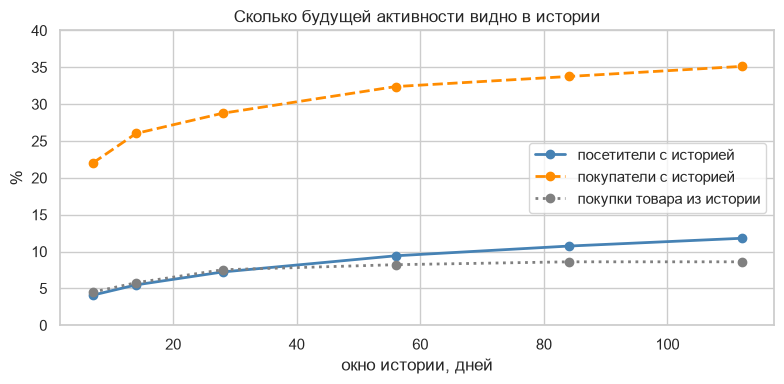

бейзлайн Марии: топ-3 до 1 июля покрывают 0.61% покупок после


In [18]:
cut = pd.Timestamp("2015-09-04")
future = events[(events["dt"] >= cut) & (events["dt"] < cut + pd.Timedelta(days=7))]
future_buy = future[future["event"] == "transaction"]
active = future["visitorid"].unique()
bought_pairs = pd.MultiIndex.from_frame(future_buy[["visitorid", "itemid"]])

rows = []
for days in [7, 14, 28, 56, 84, 112]:
    hist = events[(events["dt"] < cut) & (events["dt"] >= cut - pd.Timedelta(days=days))]
    hist_pairs = pd.MultiIndex.from_frame(hist[["visitorid", "itemid"]].drop_duplicates())
    rows.append({
        "окно истории, дней": days,
        "посетители с историей": np.isin(active, hist["visitorid"].unique()).mean(),
        "покупатели с историей": future_buy["visitorid"].isin(hist["visitorid"]).mean(),
        "покупки товара из истории": bought_pairs.isin(hist_pairs).mean(),
    })
cold = pd.DataFrame(rows).set_index("окно истории, дней")
print("активных посетителей за неделю:", len(active), "| покупок:", len(future_buy))
print((cold * 100).round(1))

fig, ax = plt.subplots(figsize=(8, 4))
for col, color, ls in zip(cold.columns, [COLOR, "darkorange", "gray"], ["-", "--", ":"]):
    ax.plot(cold.index, cold[col] * 100, color=color, ls=ls, lw=2, marker="o", label=col)
ax.set_xlabel("окно истории, дней")
ax.set_ylabel("%")
ax.set_ylim(0, 40)
ax.set_title("Сколько будущей активности видно в истории")
ax.legend()
plt.tight_layout()
plt.show()

july = pd.Timestamp("2015-07-02")
all_trans = events[events["event"] == "transaction"]
top3 = all_trans.loc[all_trans["dt"] < july, "itemid"].value_counts().head(3).index
after = all_trans[all_trans["dt"] >= july]
print("бейзлайн Марии: топ-3 до 1 июля покрывают %.2f%% покупок после"
      % (after["itemid"].isin(top3).mean() * 100))

Картина так себе. Из тех, кто зашёл на неделе, история за прошлые 8 недель есть у 9%. У покупателей получше, около трети. А купленный товар был в истории человека только в 8% случаев. Длиннее 8 недель окно брать смысла нет, кривые почти плоские

Значит, большинству посетителей главная покажется без персонализации, и там нужен нормальный запасной вариант - популярное за последние дни и по категориям. Персонально получится только для небольшой доли людей, зато самых ценных. И подбирать им надо не только уже просмотренное, но и похожее

Бейзлайн Марии 0.61% я пересчитал, сходится. С такими данными +20% к допродажам - очень смелое обещание

<a id="sec-split"></a>

## 3. Валидация

Случайное разбиение не подходит: популярность товара, посчитанная по всему датасету, уже знает будущие покупки, а на проде такого не будет. Делаю как в жизни - модель знает только прошлое и рекомендует на следующий период

Срезы раз в неделю, по пятницам. Факторы считаю по 8 неделям до среза: дальше история почти ничего не добавляет, а одинаковое окно делает срезы сравнимыми. Таргет - 7 дней после среза. Обучение на срезах 7, 14, 21 и 28 августа, валидация 4 сентября, тест 11 сентября

Недели таргета не пересекаются: у последнего обучающего среза таргет заканчивается ровно там, где начинается валидация. В истории валидации лежат недели, которые у обучения были таргетом, но это честно - к 4 сентября это уже прошлое

конец последнего таргета: 2015-09-18 00:00:00 | конец данных: 2015-09-18 02:59:47.788000


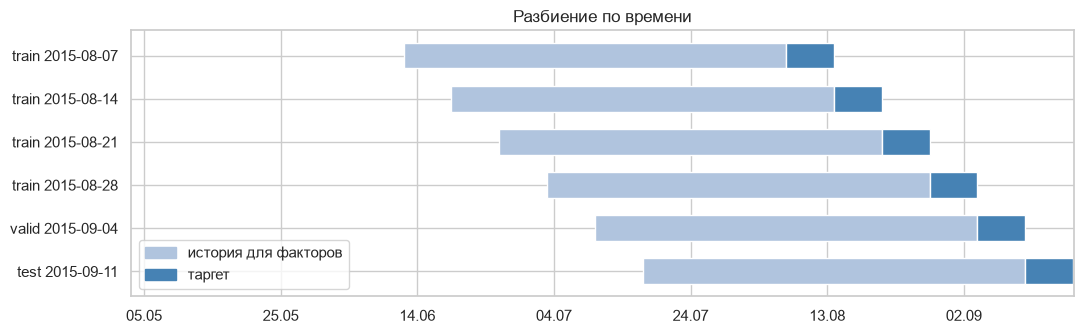

In [19]:
HIST_DAYS = 56
TARGET_DAYS = 7
CUTS = {
    "train": pd.to_datetime(["2015-08-07", "2015-08-14", "2015-08-21", "2015-08-28"]),
    "valid": pd.to_datetime(["2015-09-04"]),
    "test": pd.to_datetime(["2015-09-11"]),
}
last_end = CUTS["test"][-1] + pd.Timedelta(days=TARGET_DAYS)
print("конец последнего таргета:", last_end, "| конец данных:", events["dt"].max())

fig, ax = plt.subplots(figsize=(11, 3.5))
labels = []
for split, cuts in CUTS.items():
    for c in cuts:
        y = len(labels)
        start = mdates.date2num(c - pd.Timedelta(days=HIST_DAYS))
        ax.barh(y, HIST_DAYS, left=start, color=LIGHT, height=0.6)
        ax.barh(y, TARGET_DAYS, left=mdates.date2num(c), color=COLOR, height=0.6)
        labels.append(f"{split} {c.date()}")
ax.set_yticks(range(len(labels)))
ax.set_yticklabels(labels)
ax.invert_yaxis()
ax.set_xlim(mdates.date2num(events["dt"].min()), mdates.date2num(events["dt"].max()))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%d.%m"))
ax.legend(
    handles=[
        Patch(color=LIGHT, label="история для факторов"),
        Patch(color=COLOR, label="таргет"),
    ],
    loc="lower left",
)
ax.set_title("Разбиение по времени")
plt.tight_layout()
plt.show()

<a id="sec-feat"></a>

## 4. Факторы

На каждый срез три таблицы

По товару: просмотры, корзины, покупки и уникальные посетители, просмотры за последнюю неделю и тренд (неделя против среднего по окну), конверсии в корзину и в покупку, давность первого и последнего события. Конверсии сглаживаю к среднему по магазину, чтобы у товара с одним просмотром и одной покупкой не было 100%. Плюс категория, её корень и глубина, доступность и цена на момент среза, популярность категории и место товара в ней

По пользователю: события по типам, число товаров, сессий и дней, давность первого и последнего визита, конверсия в корзину, событий на сессию

По паре пользователь-товар: сколько раз человек смотрел товар, клал в корзину и покупал, как давно, в скольких сессиях, какую долю его просмотров занимает товар, какая доля его событий приходится на категорию товара, был ли товар в последней сессии

Кандидаты - пары из истории тех, кто пришёл в неделю таргета. Раз человек открыл главную, он активен, так что условие честное. Таргетов два: `target` - купил за неделю, `target_cart` - положил в корзину или купил. Покупок совсем мало, корзина даёт больше сигнала, а качество всё равно меряю по покупкам

In [20]:
def smooth_rate(pos, total, m=20):
    prior = pos.sum() / max(total.sum(), 1)
    return (pos + prior * m) / (total + m)


def last_value_before(prop, cut):
    part = prop_hist[(prop_hist["property"] == prop) & (prop_hist["dt"] < cut)]
    return part.groupby("itemid")["value"].last()


def count_events(df, keys, prefix):
    cnt = pd.crosstab([df[k] for k in keys], df["event"])
    cnt = cnt.reindex(columns=EVENT_TYPES, fill_value=0)
    cnt.columns = [prefix + "views", prefix + "carts", prefix + "trans"]
    return cnt


def item_features(hist, cut):
    feats = count_events(hist, ["itemid"], "i_").join(
        hist.groupby("itemid").agg(
            i_users=("visitorid", "nunique"),
            i_days_since_first=("days_ago", "max"),
            i_days_since_last=("days_ago", "min"),
        )
    )
    week_views = hist[(hist["days_ago"] <= 7) & (hist["event"] == "view")]
    feats["i_views_7d"] = (week_views.groupby("itemid").size()
                           .reindex(feats.index, fill_value=0))
    feats["i_trend"] = feats["i_views_7d"] / (feats["i_views"] / (HIST_DAYS / 7) + 1)
    feats["i_cart_rate"] = smooth_rate(feats["i_carts"], feats["i_views"])
    feats["i_trans_rate"] = smooth_rate(feats["i_trans"], feats["i_views"])

    for prop in ["category", "available", "price"]:
        feats["i_" + prop] = last_value_before(prop, cut).reindex(feats.index)
    feats["i_root"] = feats["i_category"].map(cat_root)
    feats["i_depth"] = feats["i_category"].map(cat_depth)

    cat_sum = feats.groupby("i_category")[["i_views", "i_trans"]].sum()
    feats["c_views"] = feats["i_category"].map(cat_sum["i_views"])
    feats["c_trans"] = feats["i_category"].map(cat_sum["i_trans"])
    feats["i_rank_in_cat"] = feats.groupby("i_category")["i_views"].rank(
        ascending=False, method="min"
    )
    return feats


def user_features(hist):
    feats = count_events(hist, ["visitorid"], "u_").join(
        hist.groupby("visitorid").agg(
            u_items=("itemid", "nunique"),
            u_sessions=("session", "nunique"),
            u_days=("day", "nunique"),
            u_days_since_first=("days_ago", "max"),
            u_days_since_last=("days_ago", "min"),
        )
    )
    n_events = feats[["u_views", "u_carts", "u_trans"]].sum(axis=1)
    feats["u_cart_rate"] = feats["u_carts"] / feats["u_views"].clip(lower=1)
    feats["u_events_per_session"] = n_events / feats["u_sessions"]
    return feats


def pair_features(hist, items):
    pairs = count_events(hist, ["visitorid", "itemid"], "ui_").join(
        hist.groupby(["visitorid", "itemid"]).agg(
            ui_days_since_first=("days_ago", "max"),
            ui_days_since_last=("days_ago", "min"),
            ui_sessions=("session", "nunique"),
        )
    ).reset_index()

    u_views = hist[hist["event"] == "view"].groupby("visitorid").size()
    user_views = pairs["visitorid"].map(u_views).fillna(0).clip(lower=1)
    pairs["ui_view_share"] = pairs["ui_views"] / user_views

    hist_cat = hist.assign(category=hist["itemid"].map(items["i_category"]))
    uc = hist_cat.groupby(["visitorid", "category"]).size().rename("uc_events").reset_index()
    pairs["category"] = pairs["itemid"].map(items["i_category"])
    pairs = pairs.merge(uc, on=["visitorid", "category"], how="left")
    u_total = hist.groupby("visitorid").size()
    pairs["uc_share"] = pairs["uc_events"] / pairs["visitorid"].map(u_total)
    pairs.loc[pairs["category"].isna(), "uc_share"] = np.nan

    last_session = hist.groupby("visitorid")["session"].max()
    in_last = hist[hist["session"] == hist["visitorid"].map(last_session)]
    in_last = in_last[["visitorid", "itemid"]].drop_duplicates().assign(ui_in_last_session=1)
    pairs = pairs.merge(in_last, on=["visitorid", "itemid"], how="left")
    pairs["ui_in_last_session"] = pairs["ui_in_last_session"].fillna(0).astype(int)
    return pairs.drop(columns=["category", "uc_events"])


def build_fold(events, cut):
    start = cut - pd.Timedelta(days=HIST_DAYS)
    end = cut + pd.Timedelta(days=TARGET_DAYS)
    hist = events[(events["dt"] >= start) & (events["dt"] < cut)].copy()
    hist["days_ago"] = (cut - hist["dt"]).dt.total_seconds() / 86400
    future = events[(events["dt"] >= cut) & (events["dt"] < end)]
    assert hist["dt"].max() < cut <= future["dt"].min()

    items = item_features(hist, cut)
    hist_active = hist[hist["visitorid"].isin(future["visitorid"].unique())]
    users = user_features(hist_active)
    pairs = pair_features(hist_active, items)
    pairs = pairs.merge(users, left_on="visitorid", right_index=True)
    pairs = pairs.merge(items, left_on="itemid", right_index=True)

    key = ["visitorid", "itemid"]
    bought = future.loc[future["event"] == "transaction", key].drop_duplicates()
    carted = future.loc[future["event"] != "view", key].drop_duplicates()
    pairs = pairs.merge(bought.assign(target=1), on=key, how="left")
    pairs = pairs.merge(carted.assign(target_cart=1), on=key, how="left")
    pairs[["target", "target_cart"]] = pairs[["target", "target_cart"]].fillna(0).astype(int)
    pairs["cut"] = cut
    return pairs, items

Сначала ловлю утечку. Считаю один срез на полном логе и на логе, обрезанном по срезу. Если где-то подглядываю вперёд, факторы разъедутся

In [21]:
check_cut = CUTS["valid"][0]
items_full = build_fold(events, check_cut)[1]
events_cut = events[events["dt"] < check_cut]
hist_cut = events_cut[events_cut["dt"] >= check_cut - pd.Timedelta(days=HIST_DAYS)].copy()
hist_cut["days_ago"] = (check_cut - hist_cut["dt"]).dt.total_seconds() / 86400
items_cut = item_features(hist_cut, check_cut)

pd.testing.assert_frame_equal(items_full, items_cut)
print("факторы товаров на полном и обрезанном логе совпали:", items_full.shape)
print("свойства берутся строго до среза:",
      prop_hist.loc[prop_hist["dt"] < check_cut, "dt"].max(), "<", check_cut)

факторы товаров на полном и обрезанном логе совпали: (158979, 18)
свойства берутся строго до среза: 2015-08-30 03:00:00 < 2015-09-04 00:00:00


In [22]:
folds = {}
summary = []
for split, cuts in CUTS.items():
    parts = []
    for cut in cuts:
        pairs, items = build_fold(events, cut)
        items.reset_index().assign(cut=cut).to_parquet(
            OUT / f"items_{cut.date()}.parquet", index=False
        )
        parts.append(pairs)
        summary.append({
            "split": split,
            "cut": cut.date(),
            "пар": len(pairs),
            "пользователей": pairs["visitorid"].nunique(),
            "товаров в окне": len(items),
            "target": pairs["target"].sum(),
            "target_cart": pairs["target_cart"].sum(),
        })
    folds[split] = pd.concat(parts, ignore_index=True)
    folds[split].to_parquet(OUT / f"pairs_{split}.parquet", index=False)

summary = pd.DataFrame(summary)
summary["доля target, %"] = (summary["target"] / summary["пар"] * 100).round(2)
summary

,split,cut,пар,пользователей,товаров в окне,target,target_cart,"доля target, %"
0,train,2015-08-07,36376,6831,162662,75,151,0.21
1,train,2015-08-14,35629,6935,162277,73,145,0.20
2,train,2015-08-21,36335,7121,162097,81,163,0.22
3,train,2015-08-28,36530,6888,160797,55,118,0.15
4,valid,2015-09-04,35744,7259,158979,81,137,0.23
5,test,2015-09-11,35121,6769,158026,95,161,0.27


In [23]:
train = folds["train"]
SERVICE_COLS = ["visitorid", "itemid", "cut", "target", "target_cart"]
FEATURES = [c for c in train.columns if c not in SERVICE_COLS]
print("факторов:", len(FEATURES))
print(FEATURES)
print()
print("пропуски, %:")
na = train[FEATURES].isna().mean().mul(100).round(1)
print(na[na > 0])
train[FEATURES].describe().T.round(2)

факторов: 37
['ui_views', 'ui_carts', 'ui_trans', 'ui_days_since_first', 'ui_days_since_last', 'ui_sessions', 'ui_view_share', 'uc_share', 'ui_in_last_session', 'u_views', 'u_carts', 'u_trans', 'u_items', 'u_sessions', 'u_days', 'u_days_since_first', 'u_days_since_last', 'u_cart_rate', 'u_events_per_session', 'i_views', 'i_carts', 'i_trans', 'i_users', 'i_days_since_first', 'i_days_since_last', 'i_views_7d', 'i_trend', 'i_cart_rate', 'i_trans_rate', 'i_category', 'i_available', 'i_price', 'i_root', 'i_depth', 'c_views', 'c_trans', 'i_rank_in_cat']

пропуски, %:
uc_share         11.4
i_category       11.4
i_available      10.5
i_price           9.8
i_root           11.4
i_depth          11.4
c_views          11.4
c_trans          11.4
i_rank_in_cat    11.4
dtype: float64


,count,mean,std,min,25%,50%,75%,max
ui_views,144870.0,1.54,2.33,0.0,1.00,1.00,1.00,1.450000e+02
ui_carts,144870.0,0.08,0.32,0.0,0.00,0.00,0.00,1.300000e+01
ui_trans,144870.0,0.04,0.21,0.0,0.00,0.00,0.00,1.100000e+01
ui_days_since_first,144870.0,22.36,16.58,0.0,7.27,20.20,36.10,5.600000e+01
ui_days_since_last,144870.0,21.23,16.39,0.0,6.47,18.07,34.71,5.600000e+01
ui_sessions,144870.0,1.30,1.88,1.0,1.00,1.00,1.00,1.110000e+02
ui_view_share,144870.0,0.19,0.32,0.0,0.00,0.02,0.21,1.000000e+00
uc_share,128366.0,0.34,0.39,0.0,0.01,0.12,0.70,1.000000e+00
ui_in_last_session,144870.0,0.27,0.44,0.0,0.00,0.00,1.00,1.000000e+00
u_views,144870.0,652.19,1212.02,0.0,6.00,49.00,666.00,4.564000e+03


In [24]:
fold_users = train.drop_duplicates(["visitorid", "cut"])
print("просмотров у пользователя в окне, квантили:")
print(fold_users["u_views"].quantile([0.5, 0.9, 0.99, 1]).to_dict())
threshold = fold_users["u_views"].quantile(0.99)
heavy = fold_users.loc[fold_users["u_views"] > threshold, ["visitorid", "cut"]]
is_heavy = (train[["visitorid", "cut"]].merge(heavy.assign(heavy=1), how="left")["heavy"]
            .fillna(0).astype(bool).to_numpy())
print("доля пар от топ-1%% пользователей: %.1f%%" % (is_heavy.mean() * 100))
print("доля target_cart у них: %.2f%%, у остальных: %.2f%%" % (
    train.loc[is_heavy, "target_cart"].mean() * 100,
    train.loc[~is_heavy, "target_cart"].mean() * 100,
))

просмотров у пользователя в окне, квантили:
{0.5: 2.0, 0.9: 11.0, 0.99: 84.0, 1.0: 4564.0}
доля пар от топ-1% пользователей: 45.2%
доля target_cart у них: 0.21%, у остальных: 0.55%


У обычного пользователя в окне 2 просмотра, у 1% больше 84, рекорд - 4.5 тысячи за 8 недель. Человек столько не смотрит, похоже на ботов, парсеры цен или перекупщиков. Этот 1% даёт 45% пар, а корзин у них в 2.5 раза меньше

Пока не выкидываю. Precision@3 считается по людям, у каждого три места, и в метрике у них такой же вес, как у всех. А вот в обучении их пары перетянут модель на себя, это придётся учесть - ограничить число пар на человека или взвесить строки

<a id="sec-check"></a>

## 5. Проверка факторов

Смотрю на обучении, отличаются ли пары с корзиной или покупкой от остальных. Если фактор классы не разделяет, повод подумать, нужен ли он

In [25]:
rows = []
for col in FEATURES:
    pos = train.loc[train["target_cart"] == 1, col].dropna()
    neg = train.loc[train["target_cart"] == 0, col].dropna()
    _, p = stats.mannwhitneyu(pos, neg, alternative="two-sided")
    rows.append({"фактор": col, "медиана 1": pos.median(), "медиана 0": neg.median(), "p": p})
mw = pd.DataFrame(rows).set_index("фактор").sort_values("p")
mw["медиана 1"] = mw["медиана 1"].round(2)
mw["медиана 0"] = mw["медиана 0"].round(2)
mw["p"] = mw["p"].map("{:.1e}".format)
mw

,медиана 1,медиана 0,p
фактор,,,
ui_carts,0.00,0.00,1.0e-181
i_carts,3.00,0.00,2.6e-100
i_views_7d,7.00,2.00,5.6e-80
i_days_since_last,0.37,2.39,2.7e-74
ui_days_since_last,4.35,18.13,3.4e-70
i_cart_rate,0.05,0.02,2.8e-66
ui_sessions,1.00,1.00,1.5e-62
i_trend,1.01,0.53,6.8e-58
i_trans,1.00,0.00,4.1e-54


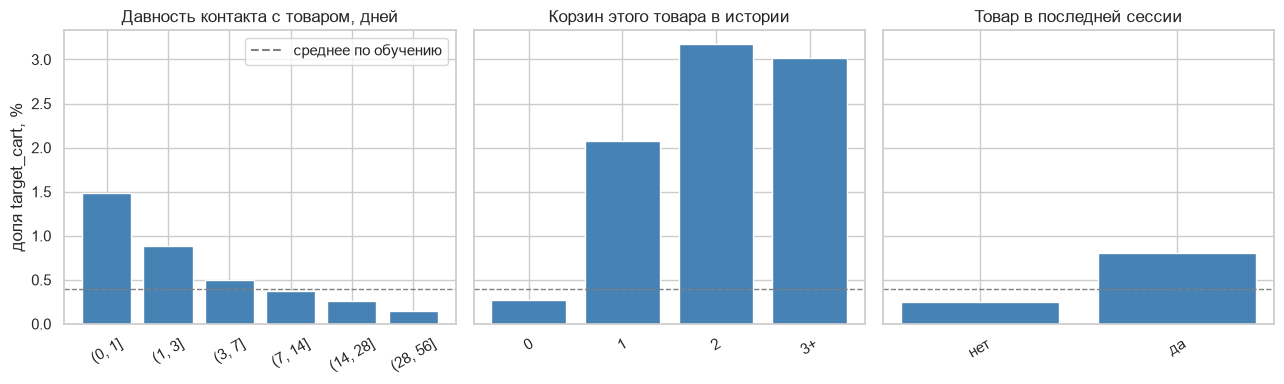

In [26]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4), sharey=True)
base = train["target_cart"].mean() * 100

recency = pd.cut(train["ui_days_since_last"], [0, 1, 3, 7, 14, 28, 56])
rate = train.groupby(recency, observed=True)["target_cart"].mean() * 100
axes[0].bar(rate.index.astype(str), rate.values, color=COLOR)
axes[0].set_title("Давность контакта с товаром, дней")

carts = train["ui_carts"].clip(upper=3)
rate = train.groupby(carts)["target_cart"].mean() * 100
axes[1].bar(["0", "1", "2", "3+"], rate.values, color=COLOR)
axes[1].set_title("Корзин этого товара в истории")

rate = train.groupby("ui_in_last_session")["target_cart"].mean() * 100
axes[2].bar(["нет", "да"], rate.values, color=COLOR)
axes[2].set_title("Товар в последней сессии")

for ax in axes:
    ax.axhline(base, color="gray", ls="--", lw=1)
    ax.tick_params(axis="x", rotation=30)
axes[0].set_ylabel("доля target_cart, %")
mean_line = plt.Line2D([], [], color="gray", ls="--", label="среднее по обучению")
axes[0].legend(handles=[mean_line])
plt.tight_layout()
plt.show()

Давность и корзина работают сильнее всего: товар, который смотрели вчера или уже клали в корзину, берут в разы чаще среднего. Ровно то, что было видно в воронке

По таблице Манна-Уитни наверху ещё свежая популярность и конверсия товара. Номер категории и корня как число ничего не разделяет, так и должно быть - это id, модели отдам его категорией

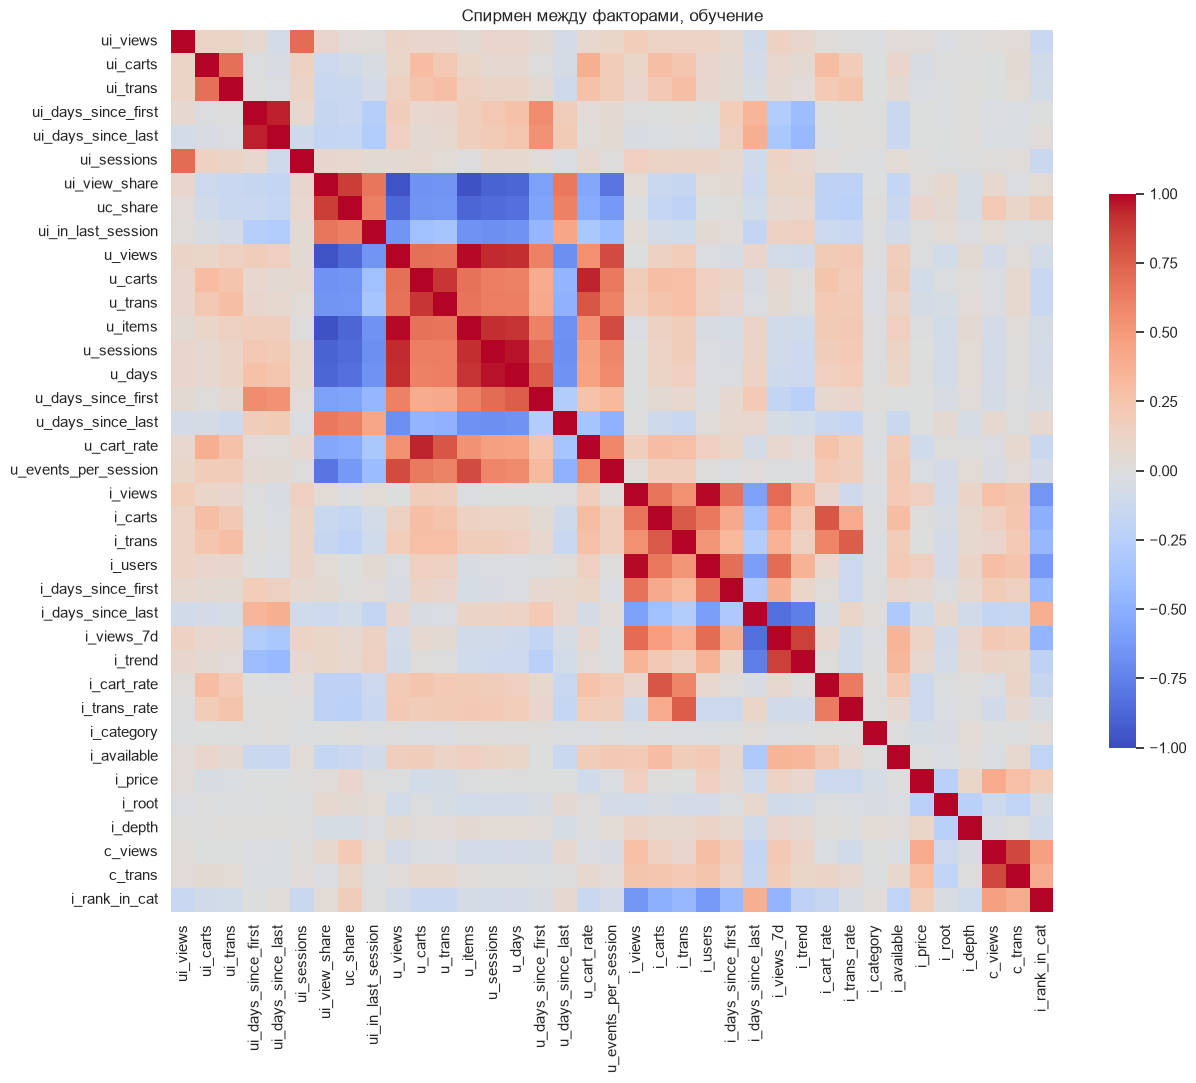

пары факторов с |rho| > 0.9:
u_views              u_items               0.990
i_views              i_users               0.985
u_sessions           u_days                0.976
ui_days_since_first  ui_days_since_last    0.952
u_carts              u_cart_rate           0.945
u_views              u_sessions            0.929
                     u_days                0.918
u_items              u_sessions            0.916
                     u_days                0.905
ui_view_share        u_views              -0.962
                     u_items              -0.970
dtype: float64


In [27]:
corr = train[FEATURES].corr(method="spearman")
fig, ax = plt.subplots(figsize=(13, 11))
sns.heatmap(corr, cmap="coolwarm", center=0, vmin=-1, vmax=1, ax=ax, square=True,
            cbar_kws={"shrink": 0.6})
ax.set_title("Спирмен между факторами, обучение")
plt.tight_layout()
plt.show()

upper = corr.where(np.triu(np.ones(corr.shape, dtype=bool), k=1)).stack()
print("пары факторов с |rho| > 0.9:")
print(upper[upper.abs() > 0.9].round(3).sort_values(ascending=False))

Почти дубли: `u_items` и `u_views`, `i_users` и `i_views`, `u_days` и `u_sessions`. `ui_view_share` зеркалит число просмотров пользователя. Деревьям это не мешает, для линейной модели оставлю по одному из пары

In [28]:
drift = pd.DataFrame({
    split: folds[split][["ui_views", "u_views", "i_views", "i_trans", "i_price"]].median()
    for split in folds
}).round(2)
print("медианы факторов по выборкам:")
drift

медианы факторов по выборкам:


,train,valid,test
ui_views,1.0,1.0,1.0
u_views,49.0,44.0,57.0
i_views,17.0,18.0,17.0
i_trans,0.0,0.0,0.0
i_price,71280.0,74760.0,74760.0


Медианы по выборкам близкие, ни один срез не выбивается. Модель на обучении и на тесте увидит похожие данные

<a id="sec-dataset"></a>

## 6. Датасет для обучения

Как из сырых файлов получается то, на чём буду учить модель:
- убираю 460 дублей из лога, время из миллисекунд перевожу в дату
- режу сессии по паузе больше 30 минут
- из свойств оставляю категорию, доступность и `790`, из дерева категорий беру корень и глубину
- для каждого среза беру события за 8 недель до него и считаю факторы товара, пользователя и пары
- свойства товара беру последним значением до среза
- кандидаты - пары из истории тех, кто появился в неделю после среза
- таргет смотрю в этой неделе: покупка и корзина или покупка
- срезы склеиваю в train, valid и test

Формат - parquet, одна строка - пара пользователь-товар на конкретном срезе. Ключи `visitorid`, `itemid`, `cut`, таргеты `target` и `target_cart`, дальше 37 факторов. Пропуски не заполняю: у товаров без свойств нет категории и цены, бустинг с NaN справится, а для линейки заполню на обучении. `i_category` и `i_root` лежат числами, но это id категорий

In [29]:
FEATURE_DESC = {
    "ui_views": "сколько раз человек смотрел товар",
    "ui_carts": "сколько раз клал товар в корзину",
    "ui_trans": "сколько раз покупал товар",
    "ui_days_since_first": "дней с первого контакта с товаром",
    "ui_days_since_last": "дней с последнего контакта с товаром",
    "ui_sessions": "в скольких сессиях был товар",
    "ui_view_share": "доля товара в просмотрах человека",
    "uc_share": "доля событий человека в категории товара",
    "ui_in_last_session": "товар был в последней сессии, 0/1",
    "u_views": "просмотры пользователя",
    "u_carts": "корзины пользователя",
    "u_trans": "покупки пользователя",
    "u_items": "разных товаров у пользователя",
    "u_sessions": "сессий",
    "u_days": "дней с активностью",
    "u_days_since_first": "дней с первого события в окне",
    "u_days_since_last": "дней с последнего события",
    "u_cart_rate": "корзины на просмотр",
    "u_events_per_session": "событий на сессию",
    "i_views": "просмотры товара",
    "i_carts": "корзины товара",
    "i_trans": "покупки товара",
    "i_users": "уникальных посетителей товара",
    "i_days_since_first": "дней с первого события по товару",
    "i_days_since_last": "дней с последнего события по товару",
    "i_views_7d": "просмотры товара за последнюю неделю",
    "i_trend": "неделя к среднему недельному по окну",
    "i_cart_rate": "сглаженная конверсия в корзину",
    "i_trans_rate": "сглаженная конверсия в покупку",
    "i_category": "категория на момент среза, id",
    "i_available": "доступность на момент среза, 0/1",
    "i_price": "свойство 790 (цена) на момент среза",
    "i_root": "корневая категория, id",
    "i_depth": "глубина категории в дереве",
    "c_views": "просмотры всех товаров категории",
    "c_trans": "покупки в категории",
    "i_rank_in_cat": "место товара в категории по просмотрам",
}
assert set(FEATURE_DESC) == set(FEATURES), set(FEATURES) ^ set(FEATURE_DESC)

levels = {"ui": "пара", "uc": "пара", "u": "пользователь", "i": "товар", "c": "категория"}
feature_table = pd.DataFrame(
    {
        "уровень": [levels[f.split("_")[0]] for f in FEATURES],
        "описание": [FEATURE_DESC[f] for f in FEATURES],
    },
    index=pd.Index(FEATURES, name="фактор"),
)
feature_table

,уровень,описание
фактор,,
ui_views,пара,сколько раз человек смотрел товар
ui_carts,пара,сколько раз клал товар в корзину
ui_trans,пара,сколько раз покупал товар
ui_days_since_first,пара,дней с первого контакта с товаром
ui_days_since_last,пара,дней с последнего контакта с товаром
ui_sessions,пара,в скольких сессиях был товар
ui_view_share,пара,доля товара в просмотрах человека
uc_share,пара,доля событий человека в категории товара
ui_in_last_session,пара,"товар был в последней сессии, 0/1"


In [30]:
for split in folds:
    saved = pd.read_parquet(OUT / f"pairs_{split}.parquet")
    assert saved.shape == folds[split].shape
    print(f"{split}: {saved.shape[0]} строк, {saved.shape[1]} колонок")
print()
print(saved[SERVICE_COLS].dtypes)

train: 144870 строк, 42 колонок
valid: 35744 строк, 42 колонок
test: 35121 строк, 42 колонок

visitorid               int64
itemid                  int64
cut            datetime64[us]
target                  int64
target_cart             int64
dtype: object


Все 37 факторов описаны, файлы читаются обратно в том же виде

<a id="sec-sum"></a>

## Итоги

Лог чистый, кроме 460 дублей. Из свойств читаются только категория и доступность, `790` похоже на цену, остальное хеши. У пятой части товаров из лога свойств нет

Воронка узкая, покупают 0.83% посетителей. Берут почти всегда то, что только что смотрели и клали в корзину, обычно в той же сессии. Популярность размазана, поэтому топ-3 на всех даёт 0.61%

Главная проблема - холодный старт. История за 8 недель есть у 9% посетителей недели и у трети покупателей, а купленный товар был в истории только в 8% случаев. Одной персонализацией тут не выехать, для большинства нужен запасной вариант на популярном и категориях

Валидация по времени: срезы по пятницам, 8 недель истории, неделя таргета. Обучение - 4 среза, 145 тысяч пар, 284 покупки и 577 корзин. Валидация 4 сентября, тест 11 сентября. Утечки нет, проверил на обрезанном логе

Факторов 37. Лучше всего классы разделяют корзина этого товара, давность контакта с ним и свежая популярность товара. Покупок в парах очень мало, 0.15-0.27%, поэтому учить скорее буду на корзине, а мерить по покупкам

Таблицы по срезам сохранил в `data/processed/`, на них дальше пробую модели